In [1]:
import sys
sys.path.append('../../Python_scripts')

In [2]:
## Import packages
from config import *
from support import *
from cosmo_support import *

In [3]:
posterior_test = np.load('posterior/cluster_MCMC_DM_ext_all.npy')

In [4]:
posterior_test.shape

(6336, 5)

In [10]:
def mcmc_plot_results(samples, param_names, savetitle=None, bins=30, target_prob=0.6827):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    
    # Create corner plot
    
    fig = corner.corner(
        samples, 
        labels=param_names,
        truths=[HUBBLE, OMEGA_MATTER, -1, 150, 0.5],
        truth_color='tab:orange',
        quantiles=[0.16, 0.5, 0.84], #quantiles=[0.5-target_prob/2, 0.5, 0.5+target_prob/2], # [0.16, 0.5, 0.84],
        q_ls=['--', ' ', '--'],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        title_fmt='.3f',
        bins=bins,
        smooth=True,
        color='tab:blue'
    )
    
    if savetitle is not None:
        plt.savefig(savetitle+"_corner_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [6]:
param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ', r'$ exp(\mu)$ ', r'$ \sigma_{\rm host}$ ']

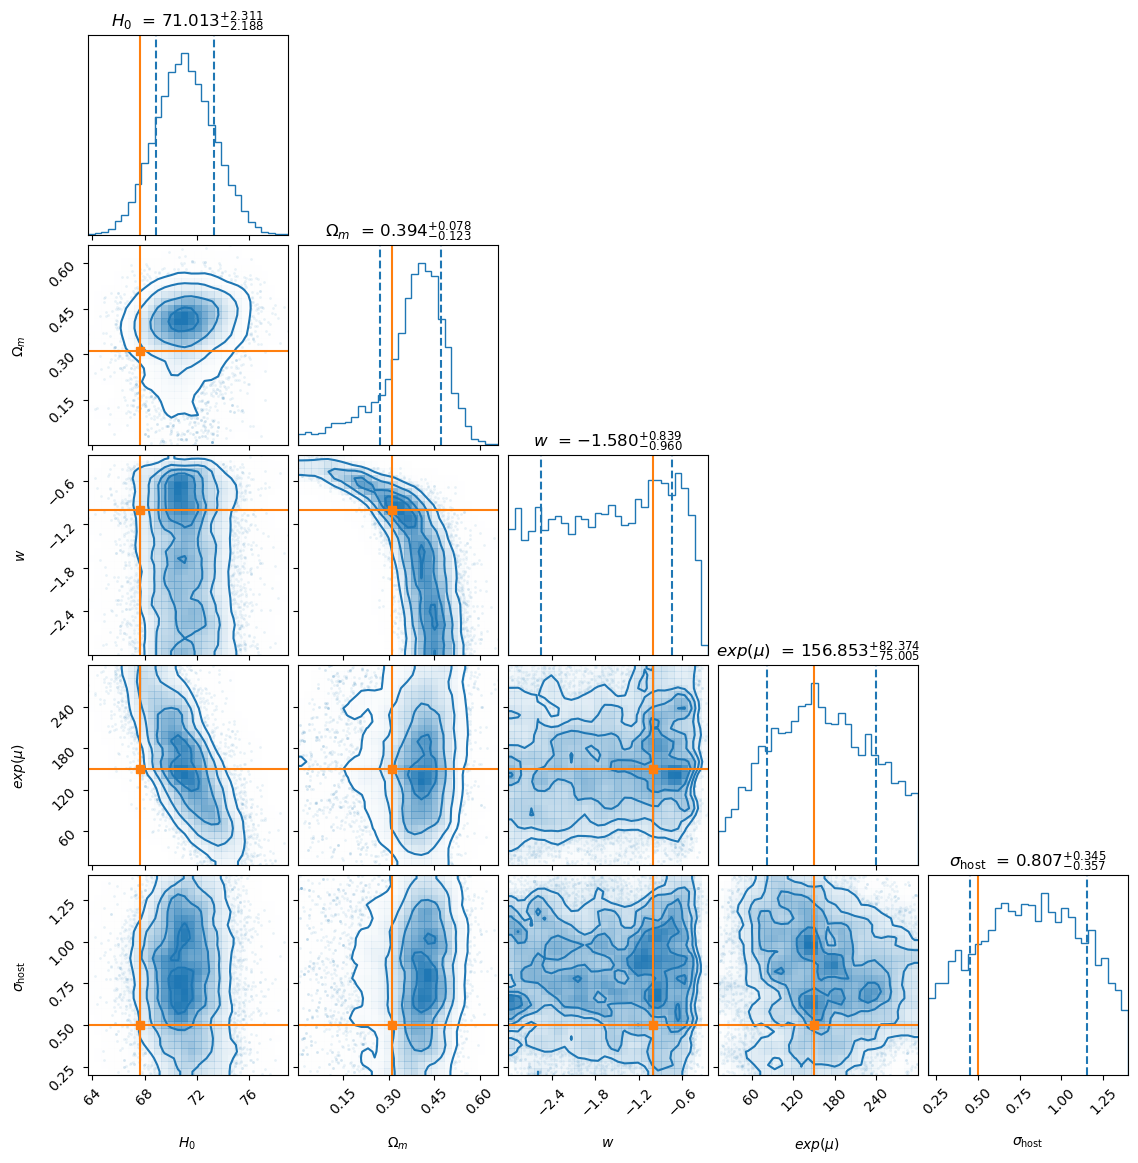

In [11]:
mcmc_plot_results(posterior_test, param_names, savetitle=None, bins=30, target_prob=0.6827)